In [1]:
import pandas as pd

df=pd.read_csv(r'C:\Users\user\OneDrive\Desktop\New folder\hotel_bookings.csv')
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [3]:

print("Datasetdəki sətir və sütunların sayı:",df.shape,end='\n\n')
print("Datasetindəki sütunlar haqqında ümumi məlumat:")
df.info()


Datasetdəki sətir və sütunların sayı: (119390, 32)

Datasetindəki sütunlar haqqında ümumi məlumat:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  flo

In [4]:
df["reservation_status_date"]=pd.to_datetime(df["reservation_status_date"])

In [5]:
print("Hər sütun üzrə null dəyərlərin cəmi:")

missing=df.isnull().sum()

for col, count in missing.items():
    if count > 0:
        print(col, count)


Hər sütun üzrə null dəyərlərin cəmi:
children 4
country 488
agent 16340
company 112593


In [6]:
#Yararsız sütunların silinməsi və null dəyərlərin əvəzlənməsi.

df.drop(columns=["agent", "company"], inplace=True)

df["children"] = df["children"].fillna(df["children"].mode()[0])
df["country"] = df["country"].fillna("Unknown")

In [7]:
print(df.duplicated().sum())

32020


In [8]:
print("Tarix sütunlarının tipinin yoxlanılması:")
print(df[["arrival_date_year","arrival_date_month","arrival_date_day_of_month","reservation_status_date"]].dtypes)


Tarix sütunlarının tipinin yoxlanılması:
arrival_date_year                     int64
arrival_date_month                      str
arrival_date_day_of_month             int64
reservation_status_date      datetime64[us]
dtype: object


In [9]:
print(df['adr'].describe().round(2))

print("Median:",df['adr'].median())

Q1 = 69.29
Q3 = 126.00

IQR = 56.71

lower = 69.29 - 1.5 * 56.71
upper = 126.00 + 1.5 * 56.71

print(lower,upper,sep='\n')

count    119390.00
mean        101.83
std          50.54
min          -6.38
25%          69.29
50%          94.58
75%         126.00
max        5400.00
Name: adr, dtype: float64
Median: 94.575
-15.774999999999991
211.065


In [10]:
print((df["adr"]<0).sum())
df.drop(df[df["adr"] < 0].index, inplace=True)

1


In [11]:
df.loc[df['adr']==df['adr'].max(),["reserved_room_type"]]

,reserved_room_type
48515,A


In [12]:
x=df.loc[df["reserved_room_type"]=='A',['reserved_room_type','adr']]
print(x,x['adr'].median(),sep='\n')

       reserved_room_type     adr
2                       A   75.00
3                       A   75.00
4                       A   98.00
5                       A   98.00
8                       A   82.00
...                   ...     ...
119383                  A   87.60
119384                  A   96.14
119385                  A   96.14
119388                  A  104.40
119389                  A  151.20

[85993 rows x 2 columns]
89.0


In [13]:
df.loc[df['adr']>500,['hotel','reserved_room_type']]

,hotel,reserved_room_type
15083,Resort Hotel,A
48515,City Hotel,A
111403,City Hotel,A


In [ ]:
df['Total_booking']=df['']

In [14]:
df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19810
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [15]:
df.groupby('market_segment')['adr'].median().round(2)

market_segment
Aviation          95.0
Complementary      0.0
Corporate         65.0
Direct           105.0
Groups            70.0
Offline TA/TO     85.5
Online TA        109.8
Undefined         15.0
Name: adr, dtype: float64

In [16]:
print("Otaq tiplərinin kateqoriyası:")
df['assigned_room_type'].value_counts()

Otaq tiplərinin kateqoriyası:


assigned_room_type
A    74053
D    25322
E     7806
F     3751
G     2553
C     2375
B     2163
H      711
I      363
K      279
P       12
L        1
Name: count, dtype: int64

In [17]:
print("Country sütununa daxil olan ölkələr")
df['country'].value_counts()

Country sütununa daxil olan ölkələr


country
PRT    48590
GBR    12128
FRA    10415
ESP     8568
DEU     7287
       ...  
NCL        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 178, dtype: int64

In [18]:
print("Həmin ölkələrə görə adr ortalaması")
df.groupby('country').agg(
    canceled_count=('is_canceled','sum'),
    adr_avg=('adr','mean')
).sort_values('canceled_count',ascending=False).head(10).round(2)

Həmin ölkələrə görə adr ortalaması


,canceled_count,adr_avg
country,,
PRT,27519,92.04
GBR,2453,96.03
ESP,2177,117.00
FRA,1934,109.62
ITA,1333,113.95
DEU,1218,104.40
IRL,832,98.19
BRA,830,111.01
USA,501,122.99


In [19]:
df['is_canceled'].corr(df['days_in_waiting_list']).round(2)

np.float64(0.05)

In [20]:
df.groupby("is_canceled")["days_in_waiting_list"].mean().round(2)

is_canceled
0    1.59
1    3.56
Name: days_in_waiting_list, dtype: float64

In [21]:
df["lead_time"].corr(df["is_canceled"]).round(2)

np.float64(0.29)

In [22]:
df.groupby("is_canceled")["lead_time"].mean().round(2)


is_canceled
0     79.98
1    144.85
Name: lead_time, dtype: float64

In [26]:
İllik_adr_ortalaması=df.groupby('arrival_date_year')['adr'].median().round(2)
İllik_adr_ortalaması

arrival_date_year
2015     77.76
2016     90.95
2017    107.10
Name: adr, dtype: float64

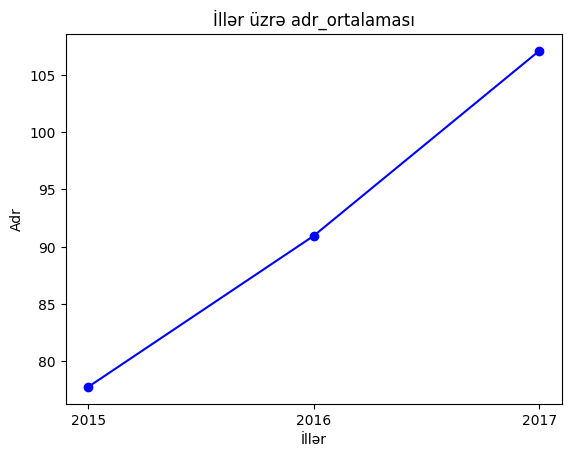

<Figure size 640x480 with 0 Axes>

In [35]:

İllik_adr_ortalaması=df.groupby('arrival_date_year')['adr'].median().round(2)

import matplotlib.pyplot as plt

plt.plot(İllik_adr_ortalaması.index,İllik_adr_ortalaması.values,color='Blue',marker='o')
plt.xticks(İllik_adr_ortalaması.index)
plt.title("İllər üzrə adr_ortalaması")
plt.xlabel("İllər")
plt.ylabel("Adr")
plt.show()
plt.tight_layout()